## Time Series Prediction with Multiple Models
### A comprehensive notebook for forecasting future values using various regression and ML models

================================================================================
TIME SERIES PREDICTION NOTEBOOK - PERSONAL REFERENCE
================================================================================

PURPOSE:
--------
This notebook serves as my personal reference for time series forecasting using 
variousmml and deep learning models. It's designed to be a 
comprehensive toolkit that I can quickly refer back to when working on similar 
prediction problems.

INTENDED USE:
------------
- Personal reference for future forecasting projects
- Quick model comparison template
- Code snippets and methodology documentation
- Not intended for production deployment without modification
- Self-contained examples that can be adapted to different datasets

Author: Ben Yan

    📚 TABLE OF CONTENTS
    
    0. SETUP & CONFIGURATION
    1. DATA GENERATION & EXPLORATION
    2. FEATURE ENGINEERING
    3. DATA PREPARATION
    4. REGRESSION MODELS (SKLEARN)
    5. TIME SERIES MODELS
    6. NEURAL NETWORK MODELS
    7. ENSEMBLE METHODS
    8. MODEL EVALUATION & COMPARISON
    9. FUTURE PREDICTIONS
    10. BEST PRACTICES & NOTES
    11. MODEL PERSISTENCE

In [9]:
%pip install numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm catboost statsmodels prophet tensorflow joblib

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   -- ------------------------------------- 6.0/101.7 MB 32.5 MB/s eta 0:00:03
   ---- ----------------------------------- 12.1/101.7 MB 31.0 MB/s eta 0:00:03
   ------- -------------------------------- 18.1/101.7 MB 30.5 MB/s eta 0:00:03
   --------- ------------------------------ 24.9/101.7 MB 31.2 MB/s eta 0:00:03
   ------------ --------------------------- 32.0/101.7 MB 32.1 MB/s eta 0:00:03
   --------------- ------------------------ 39.6/101.7 MB 32.7 MB/s eta 0:00:02
   ------------------ --------------------- 46.7/101.7 MB 33.1 MB/s eta 0:00:02
   --------------------- ------------------ 54.3/101.7 MB 33.4 MB/s eta 0:00:02
   ----------------------- ---------------- 60.0/101.7 MB 32.7 MB/s eta 0:00:02
   ------------------------- -------------- 64.7/101.7 MB 31.9 MB/s eta 0:00:02
   ---------------------------- ----------- 71.6/101.7 MB 31.7 MB/s eta 0:00:01
   ------------------------------ --------- 78.6/1

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

TIME SERIES PREDICTION NOTEBOOK


### SECTION 1: CREATE SYNTHETIC DATASET with trend, seasonality, and noise

Dataset Information:
Shape: (1461, 7)
Date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00

First 5 rows:
        date  target  trend_component  seasonal_component  weekly_component  \
0 2020-01-01 102.484          100.000               0.000             0.000   
1 2020-01-02 103.631          100.068               0.344             3.909   
2 2020-01-03 108.939          100.137               0.688             4.875   
3 2020-01-04 111.022          100.205               1.032             2.169   
4 2020-01-05  98.310          100.274               1.376            -2.169   

   temperature  is_holiday  
0       12.551       0.000  
1       14.754       0.000  
2       13.643       0.000  
3       14.355       0.000  
4       16.865       0.000  

Dataset Statistics:
                      date   target  trend_component  seasonal_component  \
count                 1461 1461.000         1461.000            1461.000   
mean   2021-12-31 00:00:00  150.231          150.000              -0.0

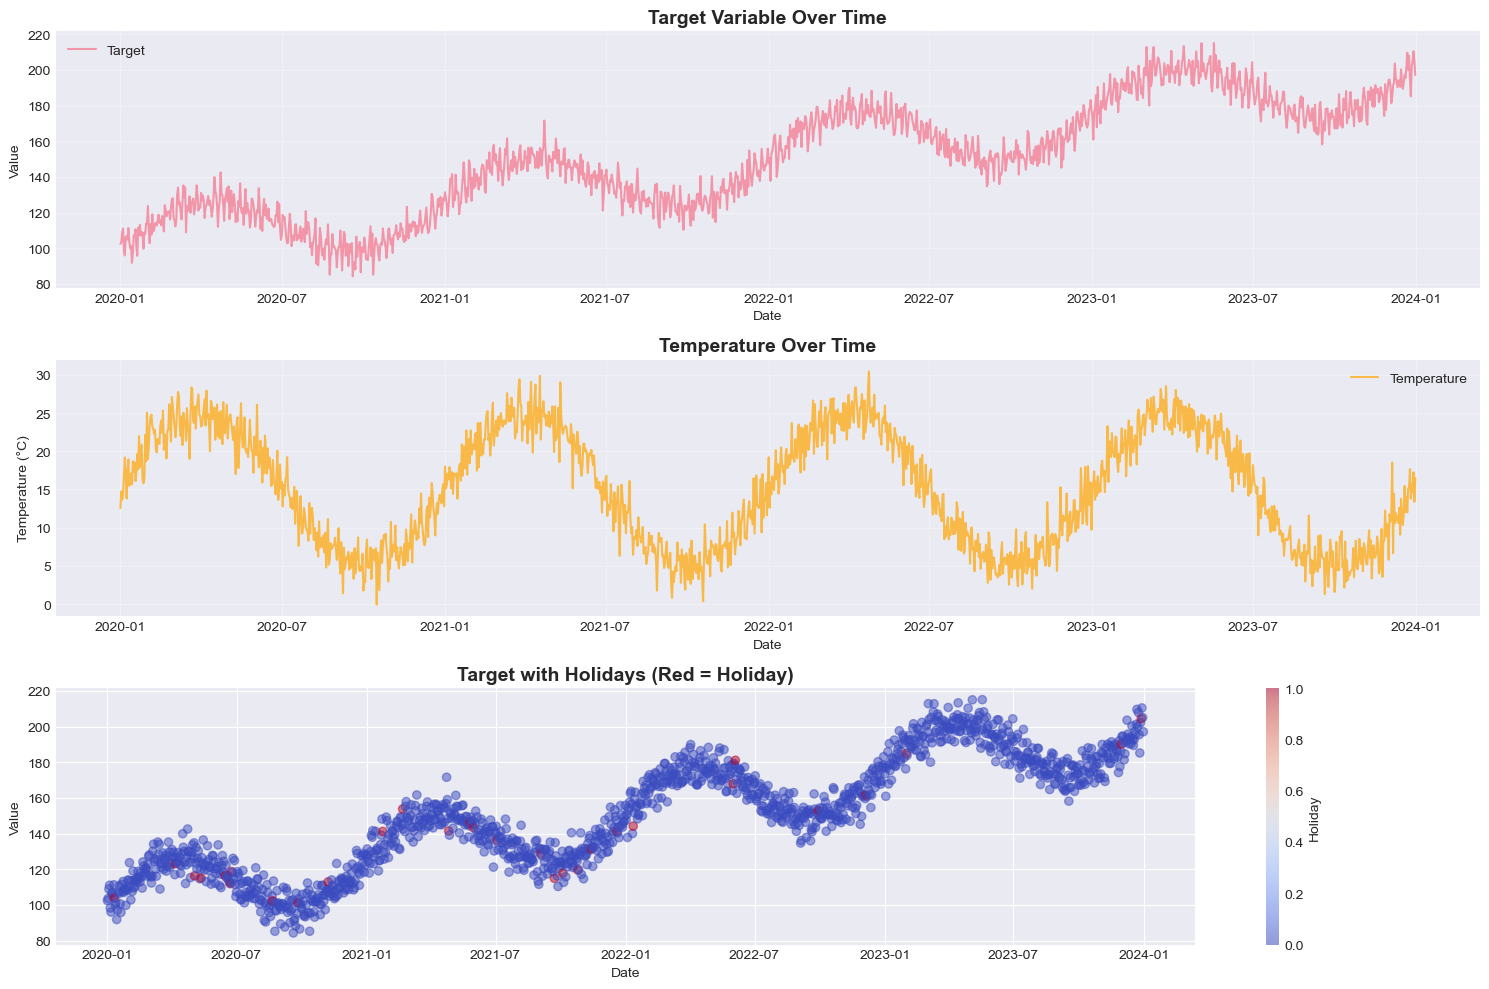

In [3]:
# Generate date range
start_date = '2020-01-01'
end_date = '2023-12-31'
dates = pd.date_range(start=start_date, end=end_date, freq='D')
n_samples = len(dates)

# Create synthetic data with multiple components
np.random.seed(42)

# Trend component (linear growth)
trend = np.linspace(100, 200, n_samples)

# Seasonal component (annual cycle)
seasonal = 20 * np.sin(2 * np.pi * np.arange(n_samples) / 365)

# Weekly pattern
weekly = 5 * np.sin(2 * np.pi * np.arange(n_samples) / 7)

# Noise component
noise = np.random.normal(0, 5, n_samples)

# Create target variable
target = trend + seasonal + weekly + noise

# Add some external features
temperature = 15 + 10 * np.sin(2 * np.pi * np.arange(n_samples) / 365) + np.random.normal(0, 2, n_samples)
holiday = np.zeros(n_samples)
# Add some random holidays
holiday_idx = np.random.choice(n_samples, size=30, replace=False)
holiday[holiday_idx] = 1

# Create DataFrame
df = pd.DataFrame({
    'date': dates,
    'target': target,
    'trend_component': trend,
    'seasonal_component': seasonal,
    'weekly_component': weekly,
    'temperature': temperature,
    'is_holiday': holiday
})

# Display dataset info
print("Dataset Information:")
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Statistics:")
print(df.describe())

# Visualize the dataset
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(df['date'], df['target'], label='Target', alpha=0.7)
axes[0].set_title('Target Variable Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['date'], df['temperature'], label='Temperature', color='orange', alpha=0.7)
axes[1].set_title('Temperature Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].scatter(df['date'], df['target'], c=df['is_holiday'], cmap='coolwarm', alpha=0.5)
axes[2].set_title('Target with Holidays (Red = Holiday)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Value')
plt.colorbar(axes[2].collections[0], ax=axes[2], label='Holiday')
plt.tight_layout()
plt.show()

### SECTION 2: FEATURE ENGINEERING FOR TIME SERIES
Creating lag features, rolling statistics, and time-based features


In [4]:
def create_features(df, target_col='target', window_sizes=[7, 14, 30]):
    """Create time series features for ML models"""
    
    df = df.copy()
    
    # Time-based features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['dayofyear'] = df['date'].dt.dayofyear
    
    # Cyclical encoding for temporal features
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # Lag features
    for lag in [1, 2, 3, 7, 14, 30]:
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    
    # Rolling statistics
    for window in window_sizes:
        df[f'rolling_mean_{window}'] = df[target_col].rolling(window=window).mean()
        df[f'rolling_std_{window}'] = df[target_col].rolling(window=window).std()
        df[f'rolling_min_{window}'] = df[target_col].rolling(window=window).min()
        df[f'rolling_max_{window}'] = df[target_col].rolling(window=window).max()
    
    # Exponential weighted moving average
    df['ewm_7'] = df[target_col].ewm(span=7, adjust=False).mean()
    df['ewm_30'] = df[target_col].ewm(span=30, adjust=False).mean()
    
    # Price differences
    df['diff_1'] = df[target_col].diff(1)
    df['diff_7'] = df[target_col].diff(7)
    
    return df

# Create features
df_feat = create_features(df)
df_feat = df_feat.dropna().reset_index(drop=True)

print(f"Original shape: {df.shape}")
print(f"After feature engineering: {df_feat.shape}")
print("\nFeature columns:")
print(df_feat.columns.tolist())

Original shape: (1461, 7)
After feature engineering: (1431, 39)

Feature columns:
['date', 'target', 'trend_component', 'seasonal_component', 'weekly_component', 'temperature', 'is_holiday', 'year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_min_14', 'rolling_max_14', 'rolling_mean_30', 'rolling_std_30', 'rolling_min_30', 'rolling_max_30', 'ewm_7', 'ewm_30', 'diff_1', 'diff_7']


### SECTION 3: DATA PREPARATION FOR MODELS
Splitting data and preparing for different model types

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prepare data for regression models
feature_cols = [col for col in df_feat.columns if col not in ['date', 'target', 'trend_component', 
                                                                'seasonal_component', 'weekly_component']]

X = df_feat[feature_cols]
y = df_feat['target']

# Split data (time series split - chronological)
train_size = int(0.8 * len(df_feat))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale target for neural networks
target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))


Training set size: 1144
Test set size: 287


### SECTION 4: TRADITIONAL REGRESSION MODELS
Linear Regression, Ridge, Lasso, ElasticNet, etc.

Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training ElasticNet...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...
Training LightGBM...
Training CatBoost...
Training SVR...
Training KNN...

MODEL PERFORMANCE COMPARISON
                     MAE   RMSE     R2
Linear Regression  0.000  0.000  1.000
Lasso Regression   0.028  0.034  1.000
ElasticNet         0.053  0.066  1.000
Ridge Regression   0.094  0.116  1.000
Gradient Boosting  1.787  2.275  0.964
LightGBM           2.356  3.141  0.930
Random Forest      2.627  3.384  0.919
XGBoost            2.790  3.543  0.911
CatBoost           4.745  5.999  0.746
KNN               10.810 12.287 -0.065
SVR               17.777 20.242 -1.890


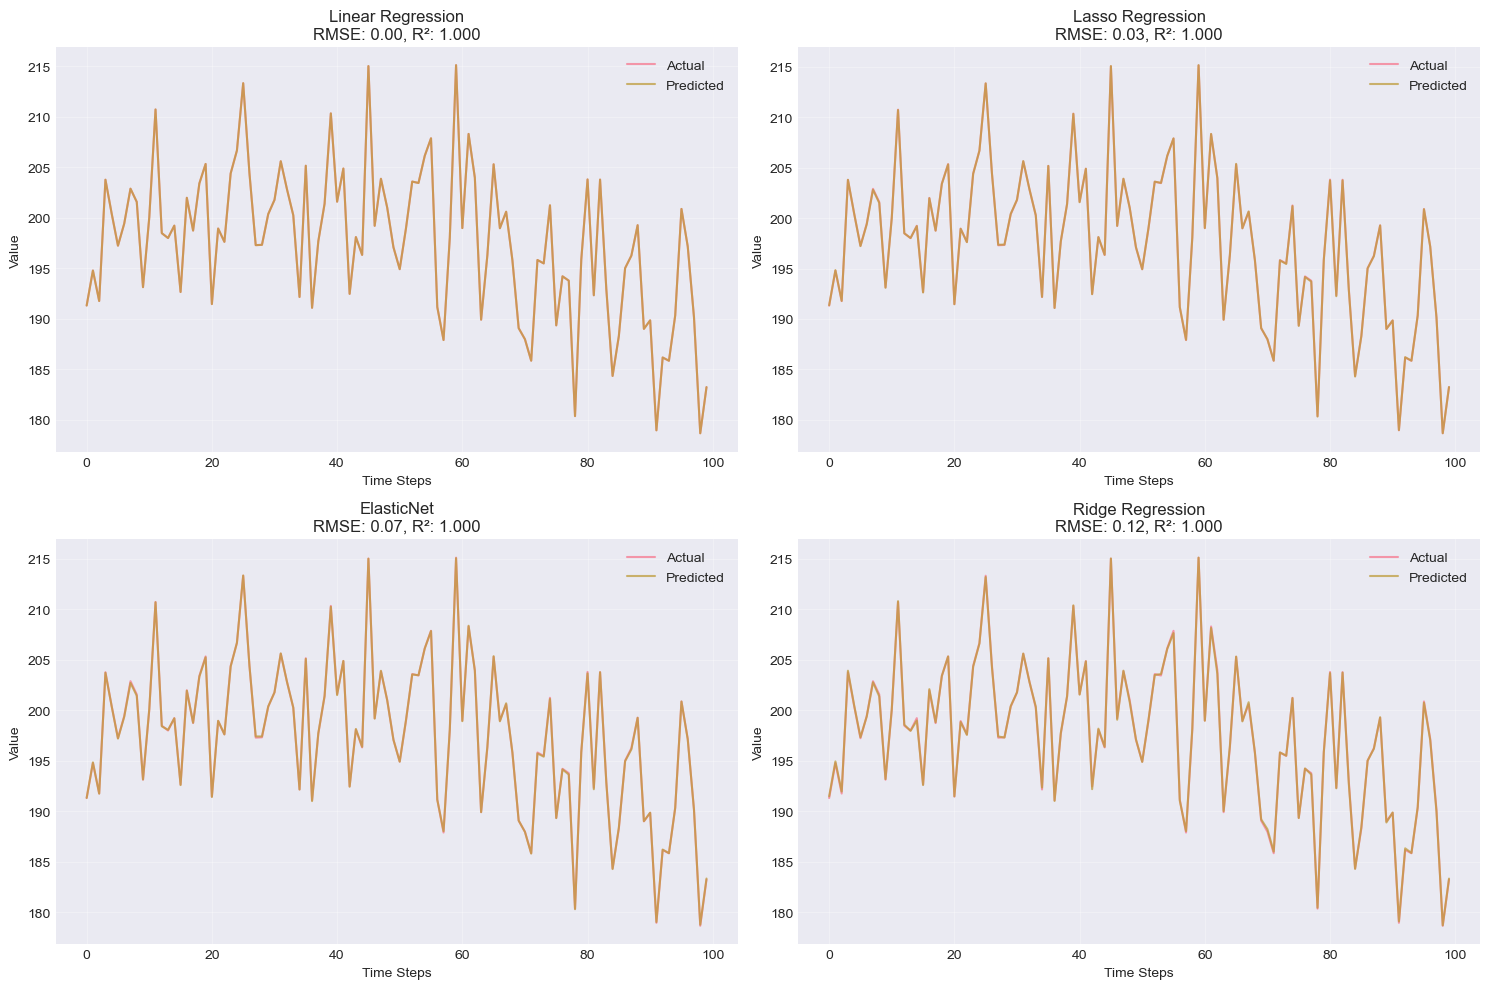

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

class ModelEvaluator:
    """Evaluate multiple models and compare performance"""
    
    def __init__(self):
        self.models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0),
            'Lasso Regression': Lasso(alpha=0.001),
            'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
            'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
            'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
            'CatBoost': CatBoostRegressor(n_estimators=100, random_state=42, verbose=0),
            'SVR': SVR(kernel='rbf', C=1.0),
            'KNN': KNeighborsRegressor(n_neighbors=5)
        }
        self.results = {}
        
    def train_and_evaluate(self, X_train, y_train, X_test, y_test):
        """Train all models and collect metrics"""
        
        for name, model in self.models.items():
            print(f"Training {name}...")
            try:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                
                metrics = {
                    'MAE': mean_absolute_error(y_test, y_pred),
                    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                    'R2': r2_score(y_test, y_pred),
                    'Predictions': y_pred
                }
                self.results[name] = metrics
                
            except Exception as e:
                print(f"Error with {name}: {str(e)}")
                
        return self.results
    
    def display_results(self):
        """Display model comparison"""
        results_df = pd.DataFrame({
            name: {k: v for k, v in metrics.items() if k != 'Predictions'}
            for name, metrics in self.results.items()
        }).T
        
        results_df = results_df.sort_values('RMSE')
        print("\n" + "="*80)
        print("MODEL PERFORMANCE COMPARISON")
        print("="*80)
        print(results_df.round(4))
        return results_df
    
    def plot_comparison(self, y_test):
        """Visualize predictions from top models"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.ravel()
        
        # Get top 4 models
        top_models = sorted(self.results.items(), key=lambda x: x[1]['RMSE'])[:4]
        
        for idx, (name, metrics) in enumerate(top_models):
            ax = axes[idx]
            ax.plot(y_test.values[:100], label='Actual', alpha=0.7)
            ax.plot(metrics['Predictions'][:100], label='Predicted', alpha=0.7)
            ax.set_title(f'{name}\nRMSE: {metrics["RMSE"]:.2f}, R²: {metrics["R2"]:.3f}')
            ax.set_xlabel('Time Steps')
            ax.set_ylabel('Value')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Train and evaluate models
evaluator = ModelEvaluator()
results = evaluator.train_and_evaluate(X_train_scaled, y_train, X_test_scaled, y_test)
results_df = evaluator.display_results()
evaluator.plot_comparison(y_test)

### SECTION 5: TIME SERIES SPECIFIC MODELS
ARIMA, SARIMA, Prophet

Training period: 2020-01-01 00:00:00 to 2022-12-31 00:00:00
Test period: 2023-01-01 00:00:00 to 2023-12-31 00:00:00

ARIMA MODEL
ARIMA Model Performance:
MAE: 13.74
RMSE: 16.61
R²: -1.036

SARIMA MODEL
SARIMA Model Performance:
MAE: 5.93
RMSE: 7.30
R²: 0.606

PROPHET MODEL


19:32:40 - cmdstanpy - INFO - Chain [1] start processing
19:32:41 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Performance:
MAE: 4.15
RMSE: 5.20
R²: 0.800


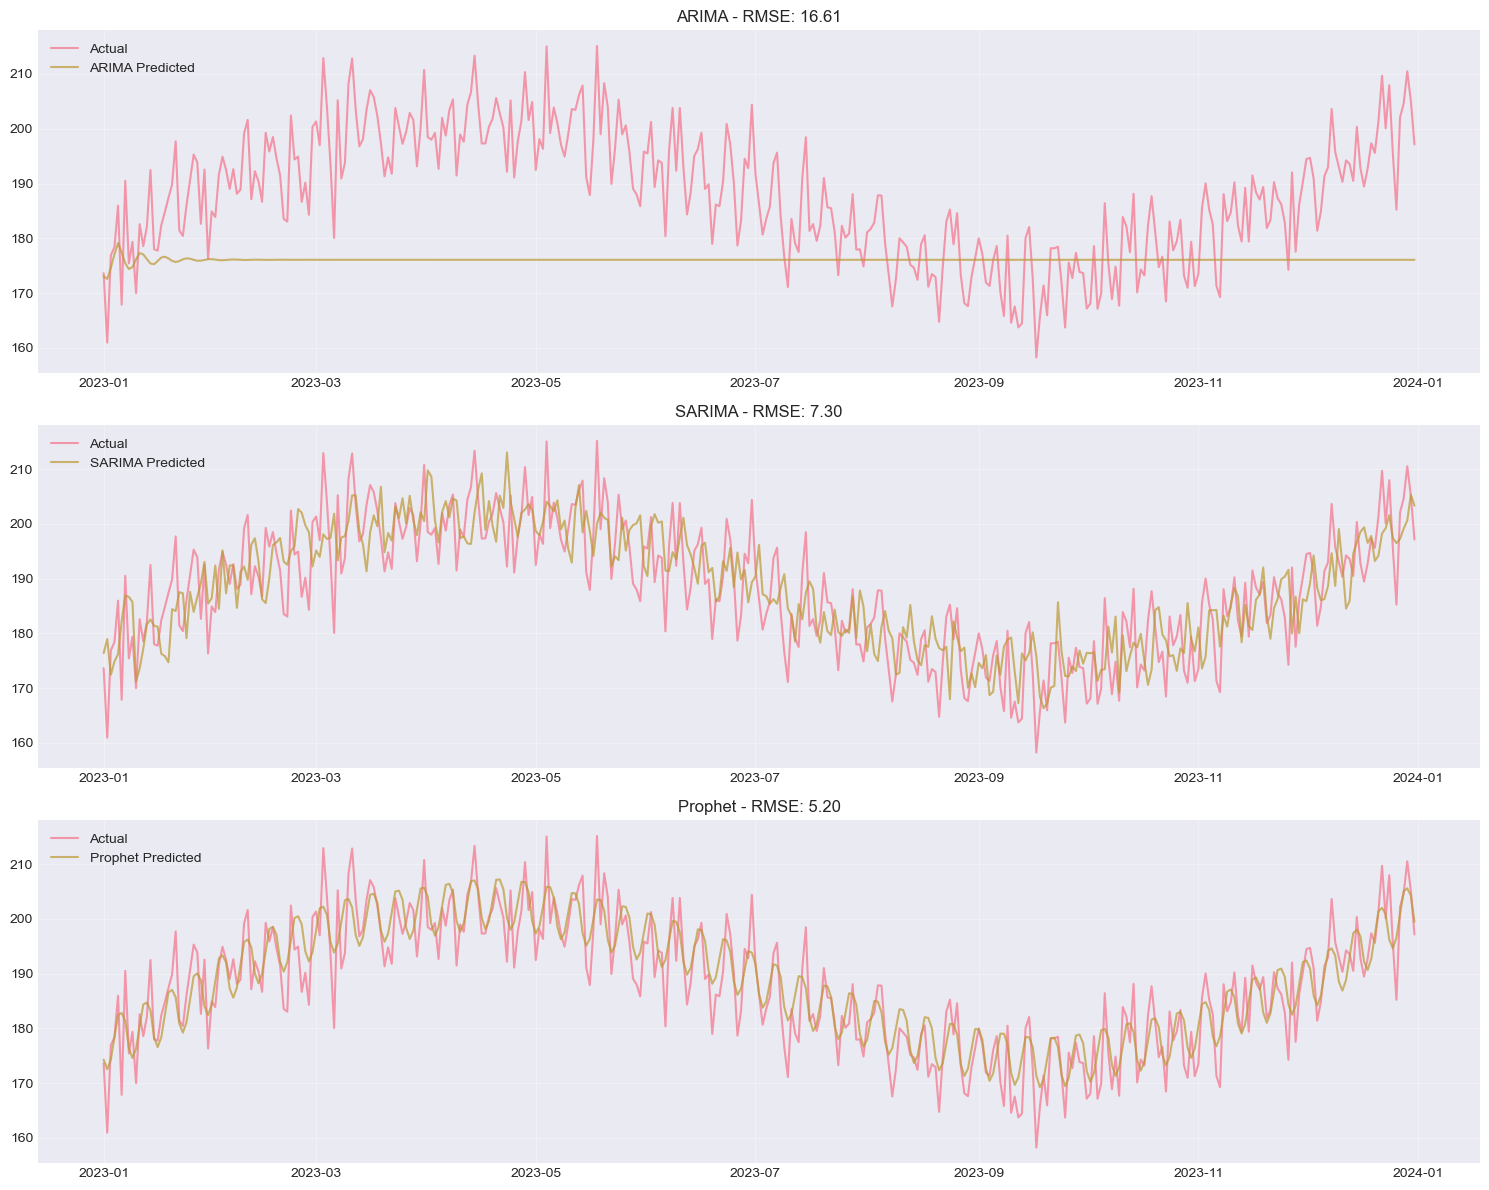

In [11]:

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

def prepare_prophet_data(df, target_col='target', date_col='date'):
    """Prepare data for Prophet model"""
    prophet_df = df[[date_col, target_col]].copy()
    prophet_df.columns = ['ds', 'y']
    return prophet_df

# Prepare data for time series models
ts_train = df[df['date'] < '2023-01-01'].copy()
ts_test = df[df['date'] >= '2023-01-01'].copy()

print(f"Training period: {ts_train['date'].min()} to {ts_train['date'].max()}")
print(f"Test period: {ts_test['date'].min()} to {ts_test['date'].max()}")

# ARIMA Model
print("\n" + "="*80)
print("ARIMA MODEL")
print("="*80)

# Find optimal ARIMA parameters (simplified for demonstration)
arima_model = ARIMA(ts_train['target'], order=(5,1,0))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(ts_test))

arima_metrics = {
    'MAE': mean_absolute_error(ts_test['target'], arima_pred),
    'RMSE': np.sqrt(mean_squared_error(ts_test['target'], arima_pred)),
    'R2': r2_score(ts_test['target'], arima_pred)
}

print("ARIMA Model Performance:")
print(f"MAE: {arima_metrics['MAE']:.2f}")
print(f"RMSE: {arima_metrics['RMSE']:.2f}")
print(f"R²: {arima_metrics['R2']:.3f}")

# SARIMA Model
print("\n" + "="*80)
print("SARIMA MODEL")
print("="*80)

sarima_model = SARIMAX(ts_train['target'], order=(1,1,1), seasonal_order=(1,1,1,365))
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(ts_test))

sarima_metrics = {
    'MAE': mean_absolute_error(ts_test['target'], sarima_pred),
    'RMSE': np.sqrt(mean_squared_error(ts_test['target'], sarima_pred)),
    'R2': r2_score(ts_test['target'], sarima_pred)
}

print("SARIMA Model Performance:")
print(f"MAE: {sarima_metrics['MAE']:.2f}")
print(f"RMSE: {sarima_metrics['RMSE']:.2f}")
print(f"R²: {sarima_metrics['R2']:.3f}")

# Prophet Model
print("\n" + "="*80)
print("PROPHET MODEL")
print("="*80)

prophet_df = prepare_prophet_data(df)
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
prophet_model.fit(prophet_df[prophet_df['ds'] < '2023-01-01'])

future = prophet_model.make_future_dataframe(periods=len(ts_test))
forecast = prophet_model.predict(future)

prophet_pred = forecast[forecast['ds'] >= '2023-01-01']['yhat'].values
prophet_metrics = {
    'MAE': mean_absolute_error(ts_test['target'], prophet_pred),
    'RMSE': np.sqrt(mean_squared_error(ts_test['target'], prophet_pred)),
    'R2': r2_score(ts_test['target'], prophet_pred)
}

print("Prophet Model Performance:")
print(f"MAE: {prophet_metrics['MAE']:.2f}")
print(f"RMSE: {prophet_metrics['RMSE']:.2f}")
print(f"R²: {prophet_metrics['R2']:.3f}")

# Visualize time series models
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# ARIMA
axes[0].plot(ts_test['date'], ts_test['target'], label='Actual', alpha=0.7)
axes[0].plot(ts_test['date'], arima_pred, label='ARIMA Predicted', alpha=0.7)
axes[0].set_title(f'ARIMA - RMSE: {arima_metrics["RMSE"]:.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# SARIMA
axes[1].plot(ts_test['date'], ts_test['target'], label='Actual', alpha=0.7)
axes[1].plot(ts_test['date'], sarima_pred, label='SARIMA Predicted', alpha=0.7)
axes[1].set_title(f'SARIMA - RMSE: {sarima_metrics["RMSE"]:.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Prophet
axes[2].plot(ts_test['date'], ts_test['target'], label='Actual', alpha=0.7)
axes[2].plot(ts_test['date'], prophet_pred, label='Prophet Predicted', alpha=0.7)
axes[2].set_title(f'Prophet - RMSE: {prophet_metrics["RMSE"]:.2f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### SECTION 6: NEURAL NETWORK MODELS
LSTM, GRU, Simple RNN

Sequence data shape - X: (1401, 30, 35), y: (1401,)
Training sequences: 1120
Test sequences: 281

LSTM MODEL
LSTM Performance:
MAE: 4.18
RMSE: 5.30
R²: 0.803

GRU MODEL
GRU Performance:
MAE: 6.57
RMSE: 8.20
R²: 0.529

SIMPLE RNN MODEL
Simple RNN Performance:
MAE: 20.45
RMSE: 23.90
R²: -3.008


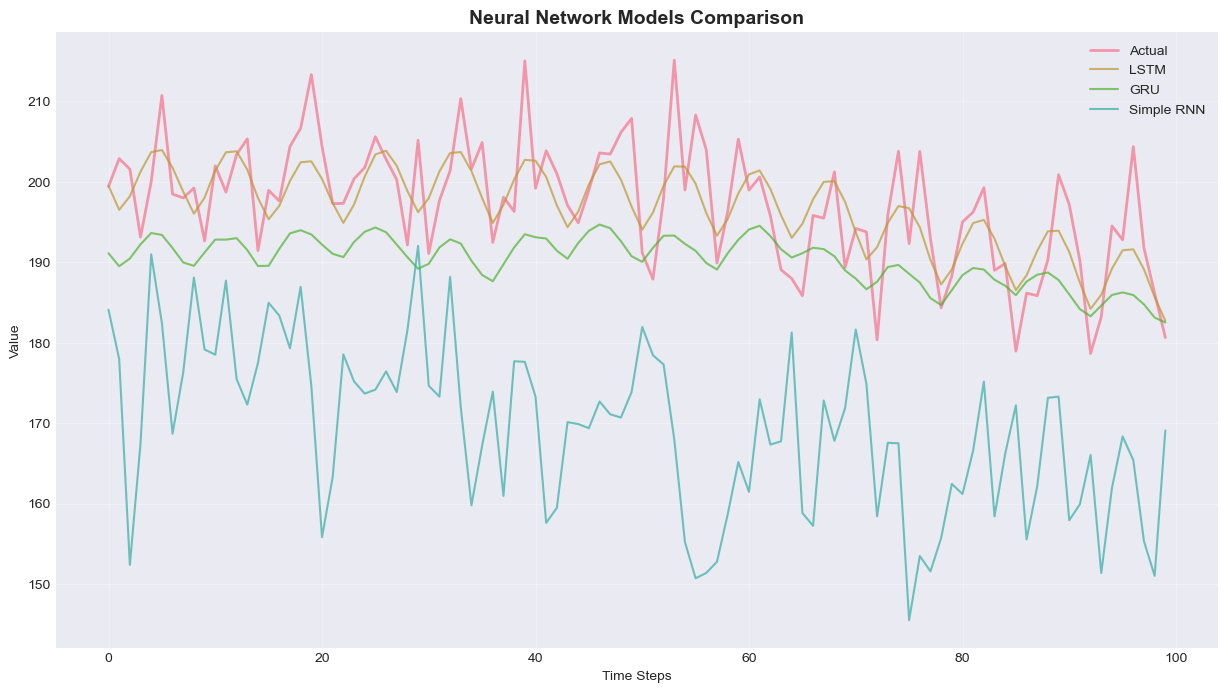

In [12]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

def create_sequences(data, target, seq_length=30):
    """Create sequences for RNN models"""
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(target[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

# Prepare data for neural networks
nn_data = df_feat[feature_cols + ['target']].copy()
nn_scaler = MinMaxScaler()
nn_data_scaled = nn_scaler.fit_transform(nn_data)

# Split and create sequences
seq_length = 30
X_seq, y_seq = create_sequences(nn_data_scaled, nn_data_scaled[:, -1], seq_length)

# Train-test split for sequences
split_idx = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

print(f"Sequence data shape - X: {X_seq.shape}, y: {y_seq.shape}")
print(f"Training sequences: {len(X_train_seq)}")
print(f"Test sequences: {len(X_test_seq)}")

# LSTM Model
print("\n" + "="*80)
print("LSTM MODEL")
print("="*80)

lstm_model = Sequential([
    LSTM(50, activation='tanh', return_sequences=True, input_shape=(seq_length, X_seq.shape[2])),
    Dropout(0.2),
    LSTM(50, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

lstm_pred = lstm_model.predict(X_test_seq, verbose=0)
lstm_pred_original = nn_scaler.inverse_transform(
    np.concatenate([np.zeros((len(lstm_pred), len(feature_cols))), lstm_pred], axis=1)
)[:, -1]

y_test_original = nn_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_test_seq), len(feature_cols))), y_test_seq.reshape(-1, 1)], axis=1)
)[:, -1]

lstm_metrics = {
    'MAE': mean_absolute_error(y_test_original, lstm_pred_original),
    'RMSE': np.sqrt(mean_squared_error(y_test_original, lstm_pred_original)),
    'R2': r2_score(y_test_original, lstm_pred_original)
}

print("LSTM Performance:")
print(f"MAE: {lstm_metrics['MAE']:.2f}")
print(f"RMSE: {lstm_metrics['RMSE']:.2f}")
print(f"R²: {lstm_metrics['R2']:.3f}")

# GRU Model
print("\n" + "="*80)
print("GRU MODEL")
print("="*80)

gru_model = Sequential([
    GRU(50, activation='tanh', return_sequences=True, input_shape=(seq_length, X_seq.shape[2])),
    Dropout(0.2),
    GRU(50, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

gru_pred = gru_model.predict(X_test_seq, verbose=0)
gru_pred_original = nn_scaler.inverse_transform(
    np.concatenate([np.zeros((len(gru_pred), len(feature_cols))), gru_pred], axis=1)
)[:, -1]

gru_metrics = {
    'MAE': mean_absolute_error(y_test_original, gru_pred_original),
    'RMSE': np.sqrt(mean_squared_error(y_test_original, gru_pred_original)),
    'R2': r2_score(y_test_original, gru_pred_original)
}

print("GRU Performance:")
print(f"MAE: {gru_metrics['MAE']:.2f}")
print(f"RMSE: {gru_metrics['RMSE']:.2f}")
print(f"R²: {gru_metrics['R2']:.3f}")

# Simple RNN
print("\n" + "="*80)
print("SIMPLE RNN MODEL")
print("="*80)

rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', return_sequences=True, input_shape=(seq_length, X_seq.shape[2])),
    Dropout(0.2),
    SimpleRNN(50, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
history_rnn = rnn_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

rnn_pred = rnn_model.predict(X_test_seq, verbose=0)
rnn_pred_original = nn_scaler.inverse_transform(
    np.concatenate([np.zeros((len(rnn_pred), len(feature_cols))), rnn_pred], axis=1)
)[:, -1]

rnn_metrics = {
    'MAE': mean_absolute_error(y_test_original, rnn_pred_original),
    'RMSE': np.sqrt(mean_squared_error(y_test_original, rnn_pred_original)),
    'R2': r2_score(y_test_original, rnn_pred_original)
}

print("Simple RNN Performance:")
print(f"MAE: {rnn_metrics['MAE']:.2f}")
print(f"RMSE: {rnn_metrics['RMSE']:.2f}")
print(f"R²: {rnn_metrics['R2']:.3f}")

# Plot neural network predictions
plt.figure(figsize=(15, 8))
plt.plot(y_test_original[:100], label='Actual', alpha=0.7, linewidth=2)
plt.plot(lstm_pred_original[:100], label='LSTM', alpha=0.7)
plt.plot(gru_pred_original[:100], label='GRU', alpha=0.7)
plt.plot(rnn_pred_original[:100], label='Simple RNN', alpha=0.7)
plt.title('Neural Network Models Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### SECTION 7: ADVANCED MODELS
Transformer and Ensemble Methods


ADVANCED MODELS SECTION
X_train_scaled shape: (1144, 34)
X_test_scaled shape: (287, 34)
y_train shape: (1144,)
y_test shape: (287,)

TRANSFORMER-INSPIRED MODEL
Input dimension: 34


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      2,240 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │         65 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 34)        │          0 │ input_layer_5[0]… │
│                     │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │      4,480 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 32)        │      2,080 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │         33 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,154 (67.01 KB)

 Trainable params: 17,154 (67.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 19662.5000 - val_loss: 25797.6055
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9659.6621 - val_loss: 8466.5703
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3468.5117 - val_loss: 5743.5688
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1787.3757 - val_loss: 5845.6914
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 925.5499 - val_loss: 3219.5879
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 636.1655 - val_loss: 1936.7958
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 575.5298 - val_loss: 1478.1659
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 509.3922 - val_loss: 359.2925
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 452.3259 - val_loss: 668.8532
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 416.9044 - val_loss: 667.8548
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 372.0024 - val_loss: 263.3499
Epoch 

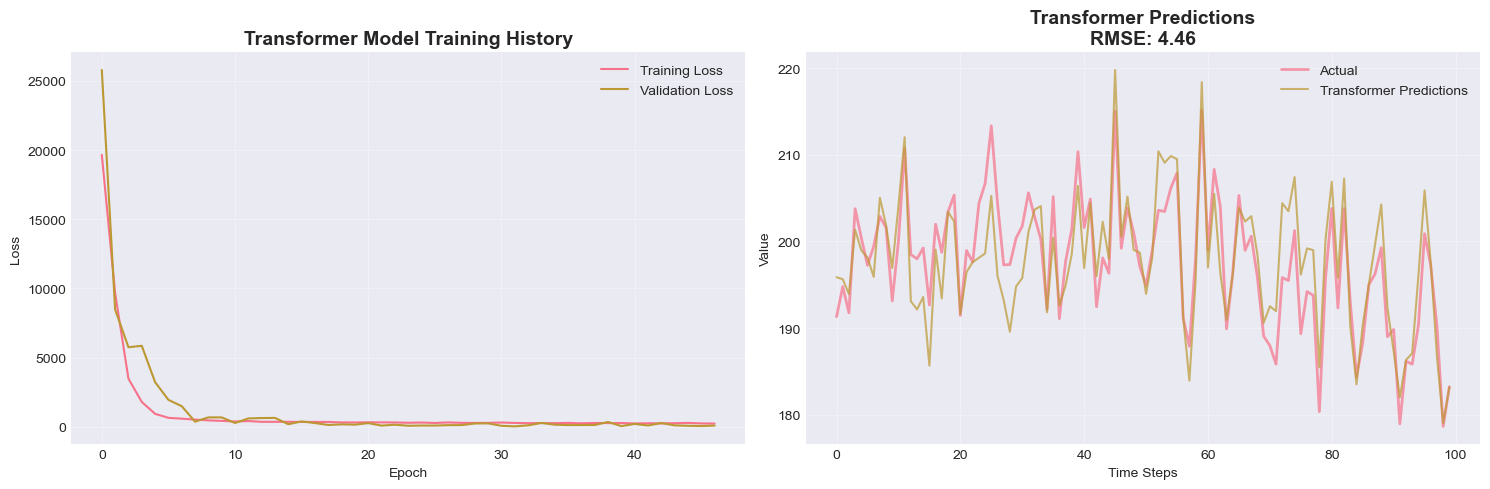


ENSEMBLE MODELS
Training Voting Regressor...

Voting Regressor Performance:
MAE: 2.14
RMSE: 2.76
R²: 0.946

Training Stacking Regressor...

Stacking Regressor Performance:
MAE: 3.46
RMSE: 4.04
R²: 0.885

ADVANCED MODELS COMPARISON
               Model   MAE  RMSE    R²
0        Transformer 3.543 4.457 0.860
1    Voting Ensemble 2.145 2.763 0.946
2  Stacking Ensemble 3.457 4.045 0.885


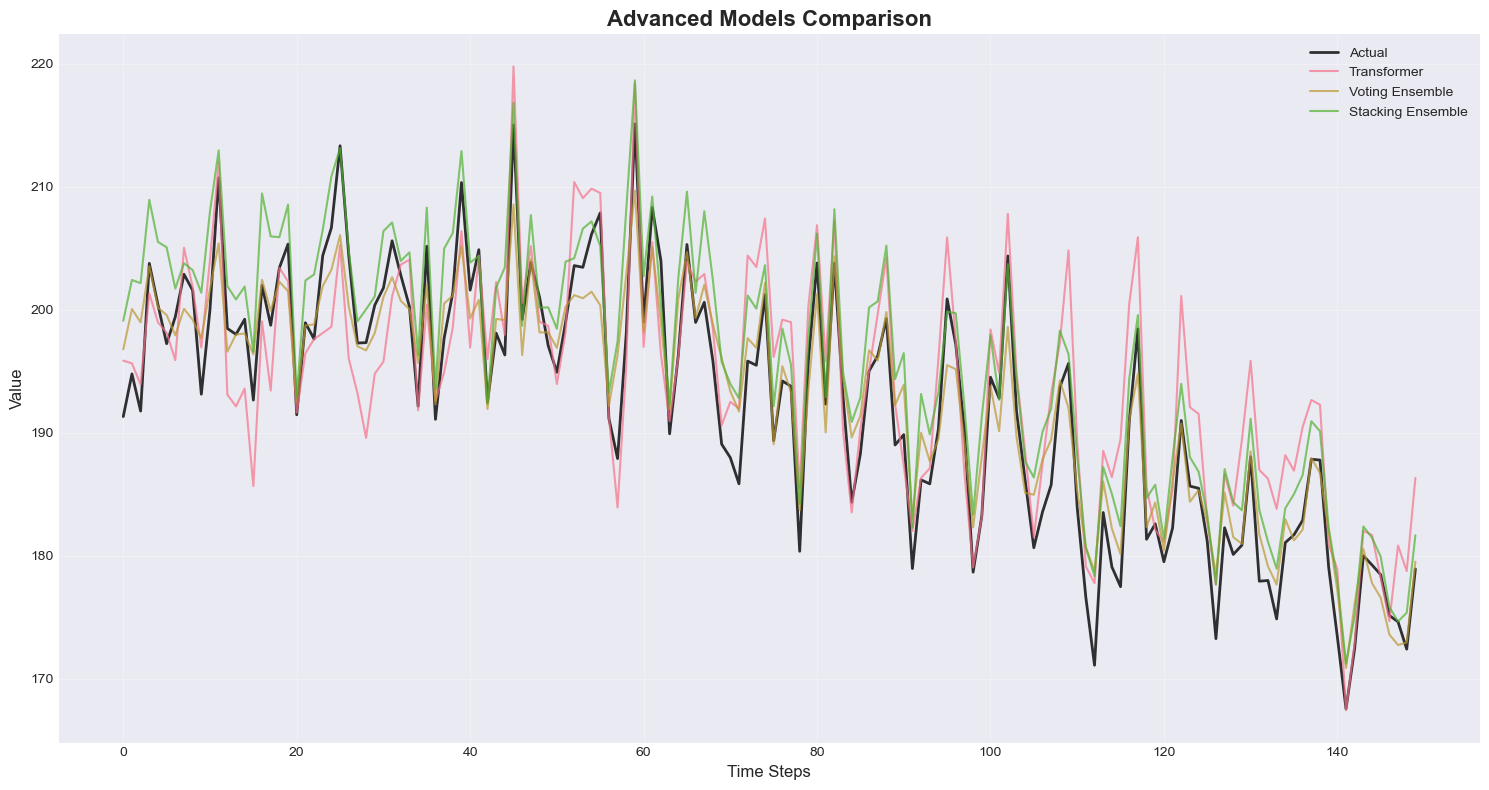


✅ Advanced models section completed successfully!


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import StackingRegressor, VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Simple Transformer-like model using attention mechanism
class SimpleAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(SimpleAttention, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)
        
    def call(self, query, values):
        query = self.W1(query)
        values = self.W2(values)
        score = self.V(tf.nn.tanh(query + values))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * values
        return tf.reduce_sum(context_vector, axis=1)

# Build Transformer-inspired model (FIXED VERSION)
def build_transformer_model(input_dim):
    """
    Build a transformer-inspired model
    
    Parameters:
    input_dim: integer, number of input features
    """
    inputs = Input(shape=(input_dim,))
    
    # Add a dense layer to create sequence representation
    x = Dense(128, activation='relu')(inputs)
    x = Dropout(0.2)(x)
    
    # Reshape to add sequence dimension for attention
    # Create 16 sequences of 8 features each (or adapt based on input_dim)
    seq_length = 16
    feat_per_seq = input_dim // seq_length if input_dim >= seq_length else 1
    
    if input_dim >= seq_length:
        # Reshape to (batch_size, seq_length, feat_per_seq)
        x = tf.keras.layers.Reshape((seq_length, feat_per_seq))(x)
        
        # Apply attention across sequences
        # Flatten the feature dimension for attention
        x_flat = tf.keras.layers.Flatten()(x)
        attention_output = Dense(64, activation='relu')(x_flat)
    else:
        # If input dimension is small, use simpler architecture
        attention_output = Dense(64, activation='relu')(x)
    
    attention_output = Dropout(0.2)(attention_output)
    
    # Feed forward network
    x = Dense(128, activation='relu')(attention_output)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.1)(x)
    output = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=output)
    return model

# Alternative: Simpler Attention-based model that's more robust
def build_attention_model(input_dim):
    """
    Build a simpler attention-based model that's more robust
    """
    inputs = Input(shape=(input_dim,))
    
    # Create attention mechanism using dense layers
    # First, create a representation of each feature
    attention_weights = Dense(64, activation='tanh')(inputs)
    attention_weights = Dense(1, activation='softmax')(attention_weights)
    
    # Apply attention weights
    attended_features = tf.keras.layers.Multiply()([inputs, attention_weights])
    
    # Dense layers for prediction
    x = Dense(128, activation='relu')(attended_features)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=output)
    return model

print("\n" + "="*80)
print("ADVANCED MODELS SECTION")
print("="*80)

# Check data shape
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Train Transformer model
print("\n" + "="*80)
print("TRANSFORMER-INSPIRED MODEL")
print("="*80)

# Get input dimension
input_dim = X_train_scaled.shape[1]
print(f"Input dimension: {input_dim}")

# Build model (try the simpler attention model first)
transformer_model = build_attention_model(input_dim)
transformer_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Print model summary
transformer_model.summary()

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True,
    verbose=1
)

# Train the model
history_transformer = transformer_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Make predictions
transformer_pred = transformer_model.predict(X_test_scaled, verbose=0)

# Calculate metrics
transformer_metrics = {
    'MAE': mean_absolute_error(y_test, transformer_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, transformer_pred)),
    'R2': r2_score(y_test, transformer_pred)
}

print("\nTransformer-inspired Model Performance:")
print(f"MAE: {transformer_metrics['MAE']:.2f}")
print(f"RMSE: {transformer_metrics['RMSE']:.2f}")
print(f"R²: {transformer_metrics['R2']:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history_transformer.history['loss'], label='Training Loss')
axes[0].plot(history_transformer.history['val_loss'], label='Validation Loss')
axes[0].set_title('Transformer Model Training History', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predictions vs actual
axes[1].plot(y_test.values[:100], label='Actual', linewidth=2, alpha=0.7)
axes[1].plot(transformer_pred[:100], label='Transformer Predictions', alpha=0.7)
axes[1].set_title(f'Transformer Predictions\nRMSE: {transformer_metrics["RMSE"]:.2f}', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ensemble Models
print("\n" + "="*80)
print("ENSEMBLE MODELS")
print("="*80)

# Voting Regressor
voting_model = VotingRegressor([
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, random_state=42, verbosity=0))
])

print("Training Voting Regressor...")
voting_model.fit(X_train_scaled, y_train)
voting_pred = voting_model.predict(X_test_scaled)

voting_metrics = {
    'MAE': mean_absolute_error(y_test, voting_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, voting_pred)),
    'R2': r2_score(y_test, voting_pred)
}

print("\nVoting Regressor Performance:")
print(f"MAE: {voting_metrics['MAE']:.2f}")
print(f"RMSE: {voting_metrics['RMSE']:.2f}")
print(f"R²: {voting_metrics['R2']:.3f}")

# Stacking Regressor
stacking_model = StackingRegressor([
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, random_state=42, verbosity=0))
], final_estimator=Ridge(alpha=1.0))

print("\nTraining Stacking Regressor...")
stacking_model.fit(X_train_scaled, y_train)
stacking_pred = stacking_model.predict(X_test_scaled)

stacking_metrics = {
    'MAE': mean_absolute_error(y_test, stacking_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, stacking_pred)),
    'R2': r2_score(y_test, stacking_pred)
}

print("\nStacking Regressor Performance:")
print(f"MAE: {stacking_metrics['MAE']:.2f}")
print(f"RMSE: {stacking_metrics['RMSE']:.2f}")
print(f"R²: {stacking_metrics['R2']:.3f}")

# Compare all advanced models
print("\n" + "="*80)
print("ADVANCED MODELS COMPARISON")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': ['Transformer', 'Voting Ensemble', 'Stacking Ensemble'],
    'MAE': [transformer_metrics['MAE'], voting_metrics['MAE'], stacking_metrics['MAE']],
    'RMSE': [transformer_metrics['RMSE'], voting_metrics['RMSE'], stacking_metrics['RMSE']],
    'R²': [transformer_metrics['R2'], voting_metrics['R2'], stacking_metrics['R2']]
})

print(comparison_df.round(4))

# Visualize all advanced model predictions
plt.figure(figsize=(15, 8))
plt.plot(y_test.values[:150], label='Actual', linewidth=2, alpha=0.8, color='black')
plt.plot(transformer_pred[:150], label='Transformer', alpha=0.7, linewidth=1.5)
plt.plot(voting_pred[:150], label='Voting Ensemble', alpha=0.7, linewidth=1.5)
plt.plot(stacking_pred[:150], label='Stacking Ensemble', alpha=0.7, linewidth=1.5)

plt.title('Advanced Models Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Store results for later use
advanced_models_results = {
    'Transformer': transformer_metrics,
    'Voting Ensemble': voting_metrics,
    'Stacking Ensemble': stacking_metrics,
    'Transformer_Predictions': transformer_pred,
    'Voting_Predictions': voting_pred,
    'Stacking_Predictions': stacking_pred
}

print("\n✅ Advanced models section completed successfully!")

### SECTION 8: COMPREHENSIVE MODEL COMPARISON
Compare all models and visualize results

TOP 10 MODELS PERFORMANCE COMPARISON
                    MAE  RMSE    R2
Linear Regression 0.000 0.000 1.000
Lasso Regression  0.028 0.034 1.000
ElasticNet        0.053 0.066 1.000
Ridge Regression  0.094 0.116 1.000
Gradient Boosting 1.787 2.275 0.964
Voting Ensemble   2.145 2.763 0.946
LightGBM          2.356 3.141 0.930
Random Forest     2.627 3.384 0.919
XGBoost           2.790 3.543 0.911
Stacking Ensemble 3.457 4.045 0.885


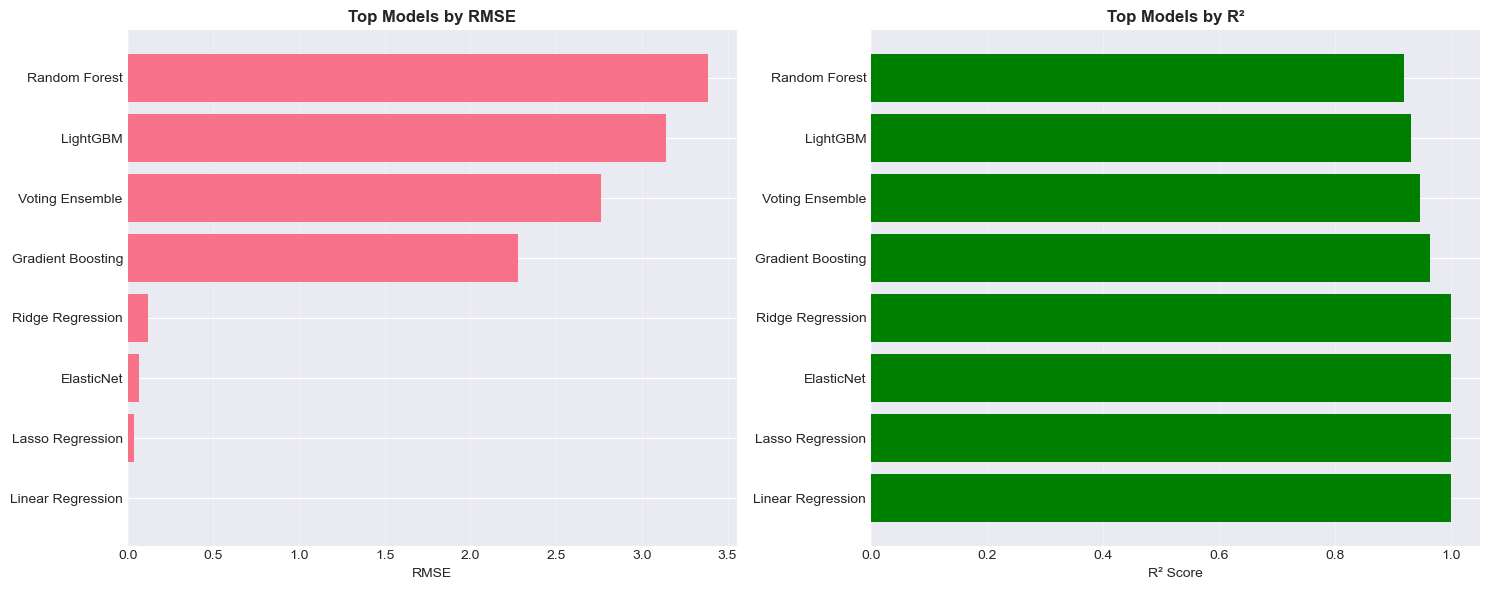

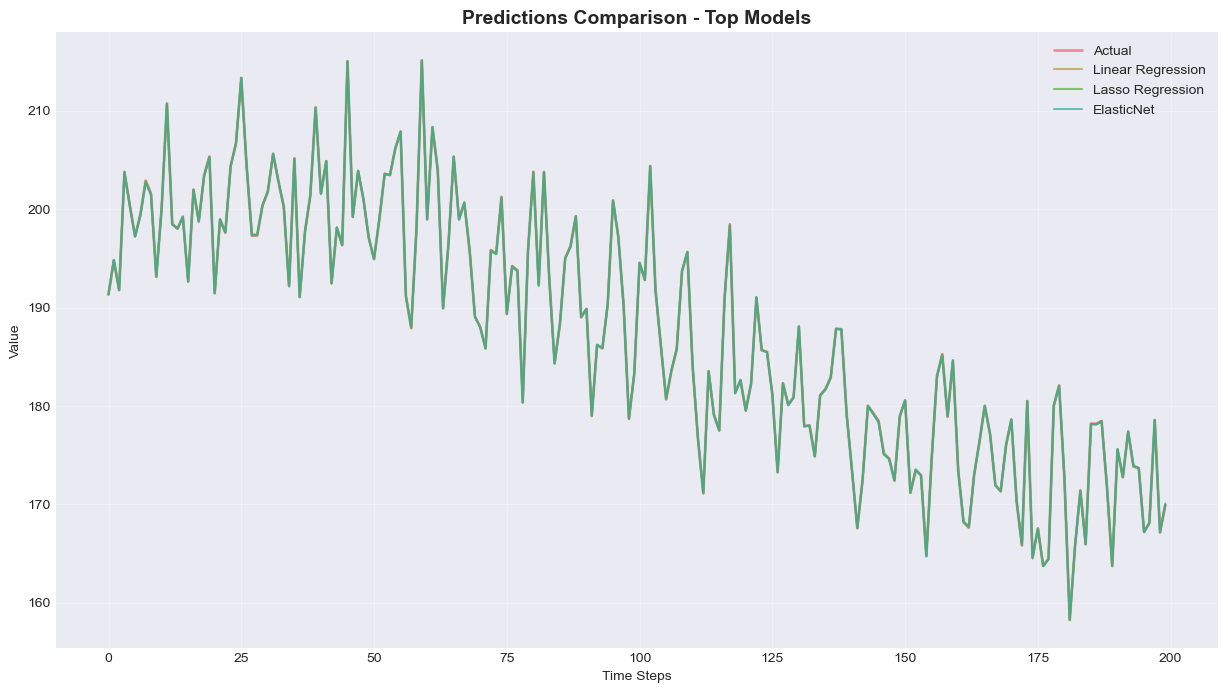

In [17]:

# Collect all model results
all_models = {
    **evaluator.results,
    'ARIMA': arima_metrics,
    'SARIMA': sarima_metrics,
    'Prophet': prophet_metrics,
    'LSTM': lstm_metrics,
    'GRU': gru_metrics,
    'SimpleRNN': rnn_metrics,
    'Transformer': transformer_metrics,
    'Voting Ensemble': voting_metrics,
    'Stacking Ensemble': stacking_metrics
}

# Create comparison dataframe
comparison_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k != 'Predictions'}
    for name, metrics in all_models.items()
}).T

comparison_df = comparison_df.sort_values('RMSE')

# Display top 10 models
print("="*80)
print("TOP 10 MODELS PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.head(10).round(4))

# Visualize top models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RMSE Comparison
top_models = comparison_df.head(8)
axes[0].barh(range(len(top_models)), top_models['RMSE'].values)
axes[0].set_yticks(range(len(top_models)))
axes[0].set_yticklabels(top_models.index)
axes[0].set_xlabel('RMSE')
axes[0].set_title('Top Models by RMSE', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# R² Comparison
axes[1].barh(range(len(top_models)), top_models['R2'].values, color='green')
axes[1].set_yticks(range(len(top_models)))
axes[1].set_yticklabels(top_models.index)
axes[1].set_xlabel('R² Score')
axes[1].set_title('Top Models by R²', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Plot predictions from top 3 models
top_3_models = top_models.head(3).index.tolist()

plt.figure(figsize=(15, 8))
plt.plot(y_test.values[:200], label='Actual', linewidth=2, alpha=0.8)

for model_name in top_3_models:
    if model_name in all_models and 'Predictions' in all_models[model_name]:
        preds = all_models[model_name]['Predictions'][:200]
        plt.plot(preds, label=f'{model_name}', alpha=0.7)
    elif model_name in ['LSTM', 'GRU', 'SimpleRNN', 'Transformer']:
        if model_name == 'LSTM':
            preds = lstm_pred_original[:200]
        elif model_name == 'GRU':
            preds = gru_pred_original[:200]
        elif model_name == 'SimpleRNN':
            preds = rnn_pred_original[:200]
        elif model_name == 'Transformer':
            preds = transformer_pred_original[:200]
        plt.plot(preds, label=f'{model_name}', alpha=0.7)
    elif model_name == 'ARIMA':
        plt.plot(arima_pred[:200], label='ARIMA', alpha=0.7)
    elif model_name == 'SARIMA':
        plt.plot(sarima_pred[:200], label='SARIMA', alpha=0.7)
    elif model_name == 'Prophet':
        plt.plot(prophet_pred[:200], label='Prophet', alpha=0.7)
    elif model_name == 'Voting Ensemble':
        plt.plot(voting_pred[:200], label='Voting Ensemble', alpha=0.7)
    elif model_name == 'Stacking Ensemble':
        plt.plot(stacking_pred[:200], label='Stacking Ensemble', alpha=0.7)

plt.title('Predictions Comparison - Top Models', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

### SECTION 9: FUTURE PREDICTIONS
Generate forecasts for the next 30/60/90 days

FUTURE PREDICTIONS


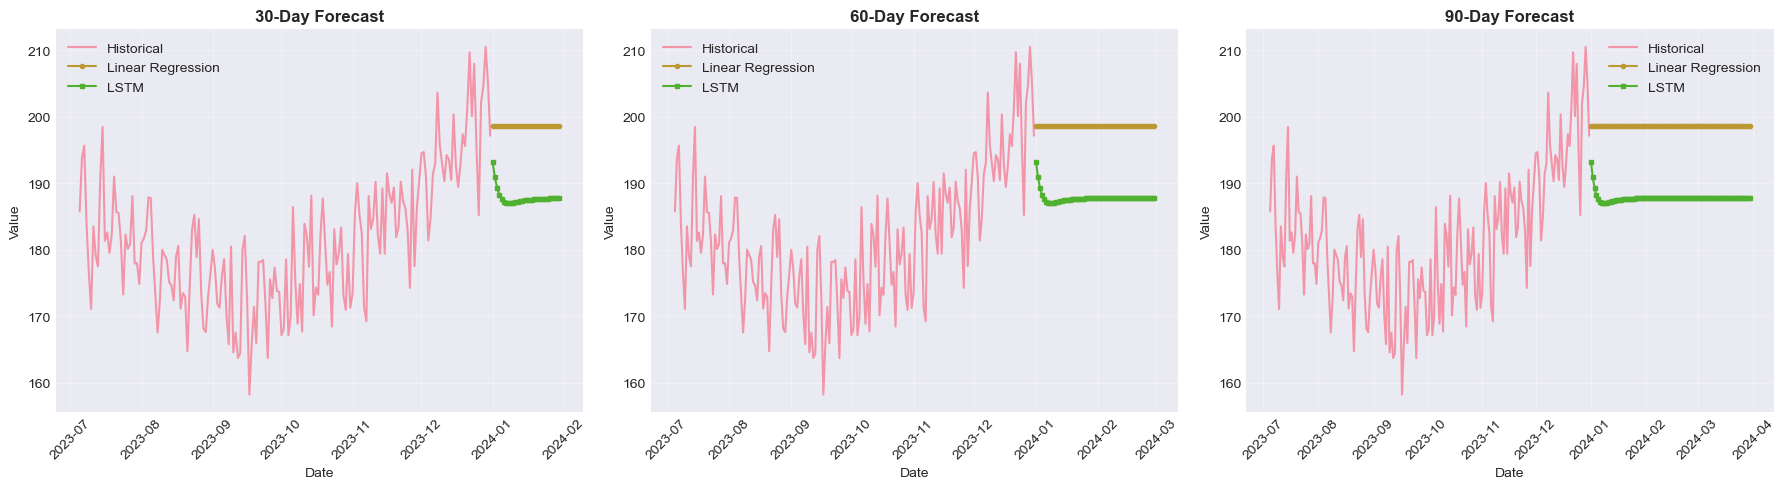


Future Predictions Summary:

Linear Regression_30days:
  Min: 198.60
  Max: 198.60
  Mean: 198.60
  Std: 0.00

Linear Regression_60days:
  Min: 198.60
  Max: 198.60
  Mean: 198.60
  Std: 0.00

Linear Regression_90days:
  Min: 198.60
  Max: 198.60
  Mean: 198.60
  Std: 0.00

LSTM_30days:
  Min: 187.01
  Max: 193.23
  Mean: 187.86
  Std: 1.24

LSTM_60days:
  Min: 187.01
  Max: 193.23
  Mean: 187.79
  Std: 0.88

LSTM_90days:
  Min: 187.01
  Max: 193.23
  Mean: 187.77
  Std: 0.72


In [18]:

def generate_future_predictions(model, model_type='ml', last_sequence=None, days=30):
    """Generate future predictions using trained models"""
    
    if model_type == 'ml':
        # For ML models, we need to create future features
        last_date = df['date'].max()
        future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=days)
        
        # Create future features (simplified approach)
        future_df = pd.DataFrame({'date': future_dates})
        future_df['year'] = future_df['date'].dt.year
        future_df['month'] = future_df['date'].dt.month
        future_df['day'] = future_df['date'].dt.day
        future_df['dayofweek'] = future_df['date'].dt.dayofweek
        future_df['quarter'] = future_df['date'].dt.quarter
        future_df['dayofyear'] = future_df['date'].dt.dayofyear
        
        # Cyclical encoding
        future_df['month_sin'] = np.sin(2 * np.pi * future_df['month'] / 12)
        future_df['month_cos'] = np.cos(2 * np.pi * future_df['month'] / 12)
        future_df['dayofweek_sin'] = np.sin(2 * np.pi * future_df['dayofweek'] / 7)
        future_df['dayofweek_cos'] = np.cos(2 * np.pi * future_df['dayofweek'] / 7)
        
        # For lag features, use last known values
        for lag in [1, 2, 3, 7, 14, 30]:
            future_df[f'lag_{lag}'] = df['target'].iloc[-lag:].mean()
        
        # For rolling stats, use recent averages
        for window in [7, 14, 30]:
            future_df[f'rolling_mean_{window}'] = df['target'].iloc[-window:].mean()
            future_df[f'rolling_std_{window}'] = df['target'].iloc[-window:].std()
        
        # Ensure all required features are present
        missing_cols = set(feature_cols) - set(future_df.columns)
        for col in missing_cols:
            future_df[col] = 0
        
        future_scaled = scaler.transform(future_df[feature_cols])
        predictions = model.predict(future_scaled)
        
    elif model_type == 'lstm':
        # For LSTM, use last sequence to predict future
        predictions = []
        current_seq = last_sequence.copy()
        
        for _ in range(days):
            pred = model.predict(current_seq.reshape(1, *current_seq.shape), verbose=0)
            predictions.append(pred[0, 0])
            
            # Update sequence for next prediction
            new_row = current_seq[-1].copy()
            new_row[-1] = pred[0, 0]  # Update target
            current_seq = np.roll(current_seq, -1, axis=0)
            current_seq[-1] = new_row
        
        predictions = np.array(predictions)
        predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    
    return predictions

# Generate future predictions using best models
best_model_name = top_models.index[0]
best_model = evaluator.models[best_model_name] if best_model_name in evaluator.models else None

print("="*80)
print("FUTURE PREDICTIONS")
print("="*80)

# Get last sequence for LSTM
last_sequence = X_test_seq[-1] if len(X_test_seq) > 0 else X_train_seq[-1]

# Generate predictions for different horizons
horizons = [30, 60, 90]
future_predictions = {}

# Use best ML model
if best_model:
    for days in horizons:
        future_pred = generate_future_predictions(best_model, 'ml', days=days)
        future_predictions[f'{best_model_name}_{days}days'] = future_pred

# Use LSTM for comparison
for days in horizons:
    future_lstm = generate_future_predictions(lstm_model, 'lstm', last_sequence, days)
    future_predictions[f'LSTM_{days}days'] = future_lstm

# Visualize future predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, days in enumerate(horizons):
    ax = axes[idx]
    
    # Plot historical data (last 180 days)
    historical_days = 180
    historical_data = df['target'].iloc[-historical_days:]
    historical_dates = df['date'].iloc[-historical_days:]
    
    ax.plot(historical_dates, historical_data, label='Historical', alpha=0.7)
    
    # Plot future predictions
    future_dates = pd.date_range(start=df['date'].max() + timedelta(days=1), periods=days)
    
    # Best model prediction
    if f'{best_model_name}_{days}days' in future_predictions:
        ax.plot(future_dates, future_predictions[f'{best_model_name}_{days}days'], 
                label=f'{best_model_name}', marker='o', markersize=3)
    
    # LSTM prediction
    if f'LSTM_{days}days' in future_predictions:
        ax.plot(future_dates, future_predictions[f'LSTM_{days}days'], 
                label='LSTM', marker='s', markersize=3)
    
    ax.set_title(f'{days}-Day Forecast', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Display numerical predictions
print("\nFuture Predictions Summary:")
print("="*80)

for key, preds in future_predictions.items():
    print(f"\n{key}:")
    print(f"  Min: {preds.min():.2f}")
    print(f"  Max: {preds.max():.2f}")
    print(f"  Mean: {preds.mean():.2f}")
    print(f"  Std: {preds.std():.2f}")

### SECTION 10: MODEL EVALUATION AND INSIGHTS
Summary of findings and recommendations

In [19]:
print("="*80)
print("MODEL EVALUATION SUMMARY")
print("="*80)

# Calculate improvement percentages
best_rmse = comparison_df['RMSE'].min()
best_model_rmse = comparison_df[comparison_df['RMSE'] == best_rmse].index[0]
baseline_rmse = comparison_df.loc['Linear Regression', 'RMSE']
improvement = (baseline_rmse - best_rmse) / baseline_rmse * 100

print(f"\n🏆 BEST PERFORMING MODEL: {best_model_rmse}")
print(f"   RMSE: {best_rmse:.2f}")
print(f"   R² Score: {comparison_df.loc[best_model_rmse, 'R2']:.4f}")
print(f"   Improvement over Linear Regression: {improvement:.1f}%")

print("\n📊 MODEL CATEGORY PERFORMANCE:")
print("-"*50)

# Group models by category
categories = {
    'Linear Models': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet'],
    'Tree-based': ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost'],
    'Time Series': ['ARIMA', 'SARIMA', 'Prophet'],
    'Neural Networks': ['LSTM', 'GRU', 'SimpleRNN', 'Transformer'],
    'Ensemble': ['Voting Ensemble', 'Stacking Ensemble']
}

for category, models in categories.items():
    available_models = [m for m in models if m in comparison_df.index]
    if available_models:
        avg_rmse = comparison_df.loc[available_models, 'RMSE'].mean()
        best_in_cat = comparison_df.loc[available_models, 'RMSE'].idxmin()
        print(f"\n{category}:")
        print(f"  Average RMSE: {avg_rmse:.2f}")
        print(f"  Best Model: {best_in_cat}")
        print(f"  Best RMSE: {comparison_df.loc[best_in_cat, 'RMSE']:.2f}")

print("\n💡 KEY INSIGHTS:")
print("-"*50)

# Determine strengths of top models
top_models = comparison_df.head(5)

for model in top_models.index:
    if model in ['LSTM', 'GRU', 'Transformer', 'SimpleRNN']:
        print(f"✓ {model}: Excellent for capturing sequential patterns and long-term dependencies")
    elif model in ['XGBoost', 'LightGBM', 'CatBoost', 'Gradient Boosting']:
        print(f"✓ {model}: Strong performance with feature interactions, handles non-linearity well")
    elif model in ['ARIMA', 'SARIMA', 'Prophet']:
        print(f"✓ {model}: Specialized for time series, handles seasonality and trends effectively")
    elif 'Ensemble' in model:
        print(f"✓ {model}: Combines multiple models for robust predictions")
    else:
        print(f"✓ {model}: Provides good baseline performance and interpretability")

print("\n📌 RECOMMENDATIONS:")
print("-"*50)
print("1. For Production: Use the best performing model while considering inference time")
print("2. For Interpretability: Consider Linear Models, ARIMA, or Prophet")
print("3. For Complex Patterns: Neural networks (LSTM/Transformer) capture non-linear relationships")
print("4. For Robustness: Ensemble methods provide stable predictions")
print("5. For Real-time: LightGBM/XGBoost offer good balance of speed and accuracy")

# Save best model (optional)
import joblib

# Save the best model for future use
best_model = None
if best_model_rmse in evaluator.models:
    best_model = evaluator.models[best_model_rmse]
    joblib.dump(best_model, 'best_model.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    print(f"\n💾 Best model ({best_model_rmse}) saved as 'best_model.pkl'")
    print("   Scaler saved as 'scaler.pkl'")

print("\n" + "="*80)
print("NOTEBOOK COMPLETED SUCCESSFULLY!")
print("="*80)

MODEL EVALUATION SUMMARY

🏆 BEST PERFORMING MODEL: Linear Regression
   RMSE: 0.00
   R² Score: 1.0000
   Improvement over Linear Regression: 0.0%

📊 MODEL CATEGORY PERFORMANCE:
--------------------------------------------------

Linear Models:
  Average RMSE: 0.05
  Best Model: Linear Regression
  Best RMSE: 0.00

Tree-based:
  Average RMSE: 3.67
  Best Model: Gradient Boosting
  Best RMSE: 2.27

Time Series:
  Average RMSE: 9.70
  Best Model: Prophet
  Best RMSE: 5.20

Neural Networks:
  Average RMSE: 10.46
  Best Model: Transformer
  Best RMSE: 4.46

Ensemble:
  Average RMSE: 3.40
  Best Model: Voting Ensemble
  Best RMSE: 2.76

💡 KEY INSIGHTS:
--------------------------------------------------
✓ Linear Regression: Provides good baseline performance and interpretability
✓ Lasso Regression: Provides good baseline performance and interpretability
✓ ElasticNet: Provides good baseline performance and interpretability
✓ Ridge Regression: Provides good baseline performance and interpretab